## Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')
import joblib
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

## Loard Data

In [2]:
# fonction de chargement de données
base_url = "https://raw.githubusercontent.com/cdg33k/HackathonIsheero_Groupe_11/main/data/"

def load_data(filename):
    return pd.read_csv(base_url + filename)

In [3]:
# chargement des données néttoyées
data = load_data("database_clean.csv")
data = data.sort_values('SQLDATE').reset_index(drop=True)
data.head(20)

,GLOBALEVENTID,SQLDATE,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,AvgTone,NumArticles,NumSources,QuadClass,Actor1Name,...,SOURCEURL,GoldsteinScale,EventRootCode,NumMentions,DATEADDED,Themes,SourceCommonName,Domaine,Region,crisis
0,1218465492,2025-01-01,Benin,9.5,2.25,3.216374,1,1,1,BENIN,...,https://dailypost.ng/2025/01/01/kebbi-state-se...,1.9,4,1,20250101214500,GENERAL_GOVERNMENT;EPU_POLICY;EPU_POLICY_GOVER...,dailypost.ng,Politique & Gouvernance,Afrique de l'Ouest,0
1,1218380721,2025-01-01,Benin,9.5,2.25,-5.305040,10,1,1,SPOKESMAN,...,https://quicknews-africa.net/police-nab-suspec...,0.0,1,10,20250101023000,SECURITY_SERVICES;TAX_FNCACT;TAX_FNCACT_POLICE...,quicknews-africa.net,Politique & Gouvernance,Panafricain,0
2,1218465490,2025-01-01,Benin,9.5,2.25,3.216374,5,1,4,BENIN,...,https://dailypost.ng/2025/01/01/kebbi-state-se...,-5.0,17,5,20250101214500,GENERAL_GOVERNMENT;EPU_POLICY;EPU_POLICY_GOVER...,dailypost.ng,Politique & Gouvernance,Afrique de l'Ouest,1
3,1218458164,2025-01-01,Benin,9.5,2.25,-7.843137,3,1,1,DIPLOMAT,...,https://www.thecable.ng/benin-republic-summons...,1.0,4,3,20250101194500,TAX_WORLDLANGUAGES;TAX_WORLDLANGUAGES_BENIN;GE...,thecable.ng,Politique & Gouvernance,Afrique de l'Ouest,0
4,1218380442,2025-01-01,Benin,9.5,2.25,-5.305040,10,1,4,POLICE,...,https://quicknews-africa.net/police-nab-suspec...,-5.0,17,10,20250101023000,SECURITY_SERVICES;TAX_FNCACT;TAX_FNCACT_POLICE...,quicknews-africa.net,Politique & Gouvernance,Panafricain,1
5,1218465489,2025-01-01,Benin,9.5,2.25,3.216374,1,1,3,BENIN,...,https://dailypost.ng/2025/01/01/kebbi-state-se...,-5.0,10,1,20250101214500,GENERAL_GOVERNMENT;EPU_POLICY;EPU_POLICY_GOVER...,dailypost.ng,Politique & Gouvernance,Afrique de l'Ouest,1
6,1218457897,2025-01-01,Benin,9.5,2.25,-8.482871,5,1,1,Unknown,...,https://punchng.com/benin-republic-summons-nig...,0.0,1,9,20250101194500,TAX_WORLDLANGUAGES;TAX_WORLDLANGUAGES_BENIN;GE...,punchng.com,Politique & Gouvernance,Afrique de l'Ouest,0
7,1218370053,2025-01-01,Benin,9.5,2.25,-5.581395,2,1,1,BENIN,...,https://guardian.ng/news/benin-protests-remark...,1.9,4,2,20250101003000,TAX_WORLDLANGUAGES;TAX_WORLDLANGUAGES_BENIN;PR...,guardian.ng,Politique & Gouvernance,Afrique de l'Ouest,0
8,1218370660,2025-01-01,Benin,9.5,2.25,-5.581395,2,1,1,NIGERIEN,...,https://guardian.ng/news/benin-protests-remark...,2.8,4,2,20250101003000,TAX_WORLDLANGUAGES;TAX_WORLDLANGUAGES_BENIN;PR...,guardian.ng,Politique & Gouvernance,Afrique de l'Ouest,0
9,1218466347,2025-01-01,Benin,9.5,2.25,-7.901235,2,1,1,BENIN,...,https://saharareporters.com/2025/01/01/benin-s...,1.0,4,2,20250101220000,TAX_WORLDLANGUAGES;TAX_WORLDLANGUAGES_BENIN;GE...,saharareporters.com,Politique & Gouvernance,Afrique de l'Ouest,0


In [4]:
data.sample(10)

,GLOBALEVENTID,SQLDATE,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,AvgTone,NumArticles,NumSources,QuadClass,Actor1Name,...,SOURCEURL,GoldsteinScale,EventRootCode,NumMentions,DATEADDED,Themes,SourceCommonName,Domaine,Region,crisis
5777,1276316177,2025-11-26,Benin,9.50000,2.25000,5.162524,2,1,3,COMMUNITY,...,https://www.graphic.com.gh/business/business-n...,-2.0,11,2,20251126174500,MEDICAL;WB_1331_HEALTH_TECHNOLOGIES;WB_1350_PH...,graphic.com.gh,Sécurité & Conflit,Afrique de l'Ouest,1
855,1225707389,2025-02-10,"Ganvie, Benin (general), Benin",6.46441,2.39288,0.900901,20,1,1,BENIN,...,https://www.gouv.bj/article/2976/le-benin-accu...,2.8,4,40,20250210194500,TAX_WORLDLANGUAGES;TAX_WORLDLANGUAGES_BENIN;TO...,gouv.bj,Économie,Afrique de l'Ouest,0
6003,1278077433,2025-12-07,Benin,9.50000,2.25000,-3.883495,10,1,1,Unknown,...,https://www.larazon.es/internacional/trece-det...,3.0,2,10,20251207174500,ARREST;SOC_GENERALCRIME;CRISISLEX_C07_SAFETY;T...,larazon.es,Politique & Gouvernance,Europe,0
4945,1266981287,2025-10-06,Benin,9.50000,2.25000,2.346041,10,1,1,DEMOCRATIC PARTY,...,https://dailytrust.com/why-our-govs-senators-o...,0.0,1,10,20251006044500,TAX_FNCACT;TAX_FNCACT_CHAIRMAN;TAX_FNCACT_VICE...,dailytrust.com,Politique & Gouvernance,Afrique de l'Ouest,0
1012,1226932696,2025-02-17,Benin,9.50000,2.25000,-8.713693,10,1,3,MILITARY,...,http://french.china.org.cn/foreign/txt/2025-02...,-7.0,13,10,20250217000000,MILITARY;TAX_MILITARY_TITLE;TAX_MILITARY_TITLE...,china.org.cn,Politique & Gouvernance,Russie & Chine,1
4543,1262791894,2025-09-12,Benin,9.50000,2.25000,5.714286,10,1,2,BENIN,...,https://benininfo.com/mode-le-benin-exporte-so...,6.4,6,10,20250912124500,TAX_WORLDLANGUAGES;TAX_WORLDLANGUAGES_BENIN;EP...,benininfo.com,Économie,Afrique de l'Ouest,0
4339,1259913885,2025-08-27,Benin,9.50000,2.25000,-1.399354,10,1,1,GOVERNOR,...,https://dailypost.ng/2025/08/27/pdp-resident-d...,0.0,1,10,20250827214500,TAX_ETHNICITY;TAX_ETHNICITY_EDO;USPEC_POLITICS...,dailypost.ng,Politique & Gouvernance,Afrique de l'Ouest,0
6543,1278439164,2025-12-09,Benin,9.50000,2.25000,13.461538,10,1,1,Unknown,...,https://www.annaharkw.com/annahar/Article.aspx...,1.0,4,10,20251209193000,LEADER;TAX_FNCACT;TAX_FNCACT_GOVERNOR;TAX_ETHN...,annaharkw.com,Politique & Gouvernance,Moyen-Orient & Afrique du Nord,0
5039,1268250282,2025-10-13,Benin,9.50000,2.25000,8.974359,10,1,1,BENIN,...,https://global.chinadaily.com.cn/a/202510/11/W...,3.4,5,10,20251013043000,TAX_FNCACT;TAX_FNCACT_AMBASSADOR;TAX_WORLDLANG...,chinadaily.com.cn,Économie,Russie & Chine,0
5443,1273176666,2025-11-08,Benin,9.50000,2.25000,5.119048,10,1,1,BENIN,...,https://www.tell.ng/emowaa-ownership-controver...,3.4,5,10,20251108191500,LEADER;TAX_FNCACT;TAX_FNCACT_GOVERNOR;TAX_ETHN...,tell.ng,Politique & Gouvernance,Afrique de l'Ouest,0


## EDA

In [5]:
# loard of graphiques
sns.set

<function seaborn.rcmod.set(*args, **kwargs)>

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7255 entries, 0 to 7254
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GLOBALEVENTID       7255 non-null   int64  
 1   SQLDATE             7255 non-null   object 
 2   ActionGeo_FullName  7255 non-null   object 
 3   ActionGeo_Lat       7255 non-null   float64
 4   ActionGeo_Long      7255 non-null   float64
 5   AvgTone             7255 non-null   float64
 6   NumArticles         7255 non-null   int64  
 7   NumSources          7255 non-null   int64  
 8   QuadClass           7255 non-null   int64  
 9   Actor1Name          7255 non-null   object 
 10  Actor2Name          7255 non-null   object 
 11  SOURCEURL           7255 non-null   object 
 12  GoldsteinScale      7255 non-null   float64
 13  EventRootCode       7255 non-null   int64  
 14  NumMentions         7255 non-null   int64  
 15  DATEADDED           7255 non-null   int64  
 16  Themes

In [7]:
data.shape

(7255, 21)

In [8]:
data.dtypes

GLOBALEVENTID           int64
SQLDATE                object
ActionGeo_FullName     object
ActionGeo_Lat         float64
ActionGeo_Long        float64
AvgTone               float64
NumArticles             int64
NumSources              int64
QuadClass               int64
Actor1Name             object
Actor2Name             object
SOURCEURL              object
GoldsteinScale        float64
EventRootCode           int64
NumMentions             int64
DATEADDED               int64
Themes                 object
SourceCommonName       object
Domaine                object
Region                 object
crisis                  int64
dtype: object

In [9]:
# verification des doublons
data.duplicated(subset=['GLOBALEVENTID'], keep=False).sum()

np.int64(0)

In [10]:
# verification des donnees manquantes
data.isna().sum()

GLOBALEVENTID           0
SQLDATE                 0
ActionGeo_FullName      0
ActionGeo_Lat           0
ActionGeo_Long          0
AvgTone                 0
NumArticles             0
NumSources              0
QuadClass               0
Actor1Name              0
Actor2Name              0
SOURCEURL               0
GoldsteinScale          0
EventRootCode           0
NumMentions             0
DATEADDED               0
Themes                214
SourceCommonName        0
Domaine                 0
Region                  0
crisis                  0
dtype: int64

In [11]:
# Detail sur les variables entières
data.describe(include = np.number)

,GLOBALEVENTID,ActionGeo_Lat,ActionGeo_Long,AvgTone,NumArticles,NumSources,QuadClass,GoldsteinScale,EventRootCode,NumMentions,DATEADDED,crisis
count,7.255000e+03,7255.000000,7255.000000,7255.000000,7255.000000,7255.000000,7255.000000,7255.000000,7255.000000,7255.000000,7.255000e+03,7255.000000
mean,1.252579e+09,9.405935,2.256338,-1.029795,7.380841,1.011578,1.735768,0.716733,6.561819,7.555203,2.025071e+13,0.246451
std,2.010340e+07,0.699415,0.177918,4.583502,4.038257,0.143332,1.092526,4.502242,5.318139,4.412518,4.851183e+08,0.430974
min,1.218370e+09,6.293860,0.968912,-18.518519,1.000000,1.000000,1.000000,-10.000000,1.000000,1.000000,2.025010e+13,0.000000
25%,1.234868e+09,9.500000,2.250000,-4.164040,4.000000,1.000000,1.000000,-2.000000,3.000000,4.000000,2.025033e+13,0.000000
50%,1.252315e+09,9.500000,2.250000,-0.771208,10.000000,1.000000,1.000000,1.900000,4.000000,10.000000,2.025072e+13,0.000000
75%,1.273203e+09,9.500000,2.250000,2.325581,10.000000,1.000000,2.000000,3.400000,9.000000,10.000000,2.025111e+13,0.000000
max,1.299592e+09,12.407400,3.694290,19.480519,48.000000,7.000000,4.000000,10.000000,19.000000,48.000000,2.026042e+13,1.000000


In [12]:
# Detail sur les variables textes
data.describe(include=object)

,SQLDATE,ActionGeo_FullName,Actor1Name,Actor2Name,SOURCEURL,Themes,SourceCommonName,Domaine,Region
count,7255,7255,7255,7255,7255,7041,7255,7255,7255
unique,349,92,549,499,4837,4524,986,8,15
top,2025-12-07,Benin,BENIN,Unknown,https://guardian.ng/politics/south-south-pdp-s...,TAX_FNCACT;TAX_FNCACT_STUDENTS;TAX_WORLDLANGUA...,lanouvelletribune.info,Politique & Gouvernance,Afrique de l'Ouest
freq,331,6559,1876,2658,9,9,590,6428,3798


In [13]:
data['SQLDATE'] = pd.to_datetime(data['SQLDATE'])

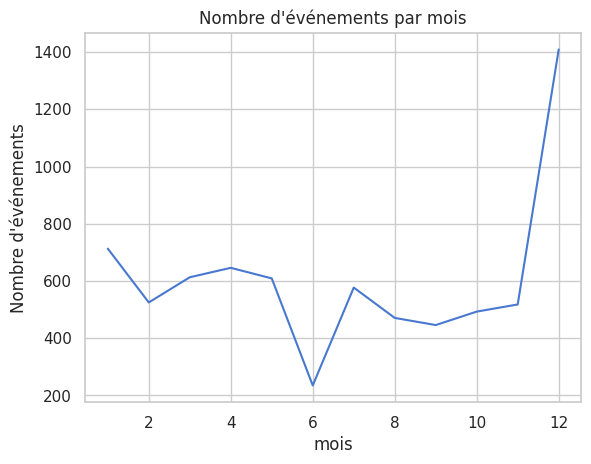

In [14]:
# Volume d'événements par mois
monthly_events = data.groupby(data['SQLDATE'].dt.month).size()
monthly_events.plot(title="Nombre d'événements par mois")
plt.xlabel("mois")
plt.ylabel("Nombre d'événements")
plt.show()

In [15]:
monthly_events.sort_values(ascending=False).head(10)

SQLDATE
12    1409
1      713
4      646
3      613
5      609
7      577
2      525
11     518
10     493
8      471
dtype: int64

On remarque une forte variabilité du nombre d’événements médiatisés au Bénin en 2025, avec des valeurs quotidiennes allant de 450 à environ 1400 événements par mois.
On observe notamment un pic en décembre, indiquant une intensification soudaine de l’attention médiatique ( cela correspond également à la période de tentative du coup d'état).

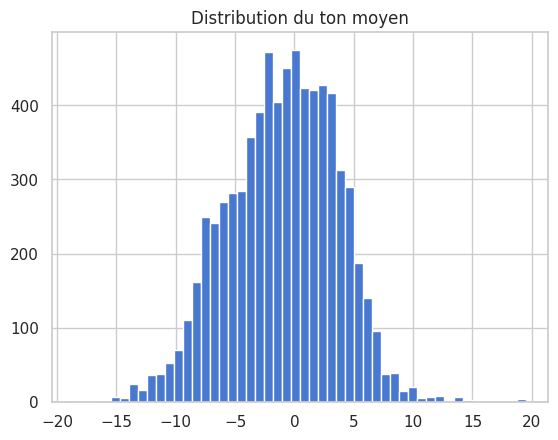

In [16]:
# Ton moyen des médias
data['AvgTone'].hist(bins=50)
plt.title("Distribution du ton moyen")
plt.show()

La distribution du ton moyen des médias présente une forme proche d’une loi normale, centrée entre -1 et 0. 
La majorité des observations se concentre autour de valeurs proches de zéro ( évènement perçu neutre par les médias) , tandis que les extrémités de la distribution traduisent à la fois la présence d’événements perçus négativement et d’autres associés à des dynamiques plus positives, avec une légère dominance des valeurs négatives. En gros, le climat médiatique en 2025, du Bénin, apparaît équilibré, sans signal clair de dérive extrême sur l’ensemble de l’année.

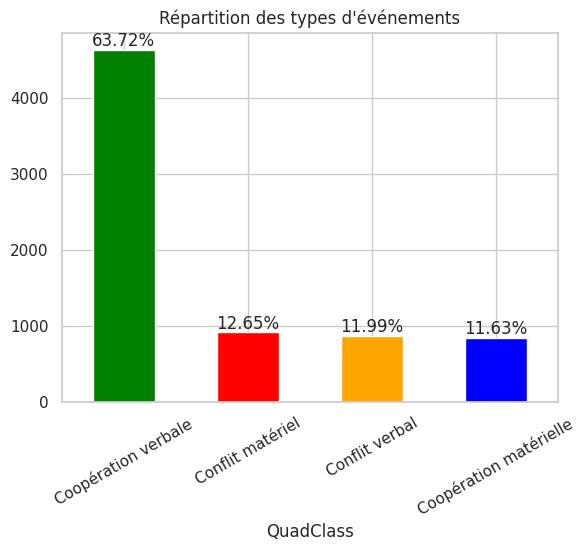

In [17]:
# distributions des conflits et / ou coopérations

# types d'evenements dans QuadClass
type_evenement = {
    1: "Coopération verbale",
    2: "Coopération matérielle",
    3: "Conflit verbal",
    4: "Conflit matériel"
}
count_eve = data['QuadClass'].map(type_evenement).value_counts()
percentages = count_eve / count_eve.sum() * 100 # pourcentage d'apparition des evenements
ax = count_eve.plot(kind='bar', color=['green', 'red', 'orange', 'blue'])
plt.title("Répartition des types d'événements")
plt.xticks(rotation=30)

# affichage des pourcentages
for i, v in enumerate(percentages):
    ax.text(i, count_eve[i], f"{v:.2f}%", ha='center', va='bottom')
    
plt.show()

On constate une nette dominance de la coopération verbale, qui représente environ 63,72% des observations. Cette prépondérance traduit une activité médiatique largement orientée vers des interactions non conflictuelles, qui peuvent être des déclarations publiques, les échanges diplomatiques ou les prises de position officielles. Les conflits, en agrégeant les formes verbales et matérielles, constituent près de 24 % des événements, ce qui reste significatif sans être majoritaire. Parmi eux, les conflits matériels, avec environ 12,65 %, dépassent légèrement les conflits verbaux, suggérant que les situations impliquant des actions concrètes ou des tensions plus marquées sont relativement présentes dans la couverture médiatique. Enfin, la coopération matérielle représente environ 11,63 % des événements, indiquant que les actions concrètes de collaboration existent mais demeurent moins fréquentes que les interactions verbales. Dans l’ensemble, l'environnement reste majoritairement coopératif, tout en révélant une présence non négligeable de dynamiques conflictuelles.

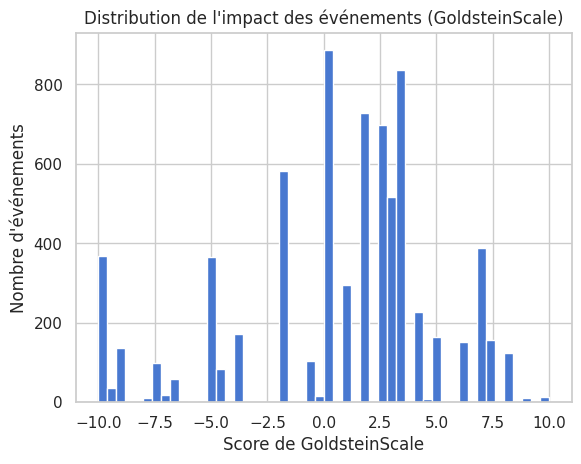

In [18]:
# Intensité des evenements
data['GoldsteinScale'].hist(bins=50)
plt.title("Distribution de l'impact des événements (GoldsteinScale)")
plt.ylabel("Nombre d'événements")
plt.xlabel("Score de GoldsteinScale")
plt.show()

In [19]:
mean_impact = data['GoldsteinScale'].mean()
median_impact= data['GoldsteinScale'].median()
mode_impact = data['GoldsteinScale'].mode()[0]

print(f"Moyenne : {mean_impact:.2f}")
print(f"Médiane : {median_impact:.2f}")
print(f"Mode    : {mode_impact:.2f}")

Moyenne : 0.72
Médiane : 1.90
Mode    : 0.00


L'analyse du Score de GoldsteinScale (Impact ou intensité de l'évènement) révèle une situation globalement stable au Bénin. Avec un mode de 0.00, la majorité des événements sont neutres, tandis que la médiane de 1.90 indique que la moitié des événements sont modérément coopératifs. La moyenne de 0.72 (légèrement positive), implique qu'il y a en moyenne, plus d'événements coopératifs que conflictuels. On remarque aussi, même peu dominants, la présence des scores négatifs.

In [20]:
# types d'evenement dominant
data['EventRootCode'].value_counts().head(10)

EventRootCode
4     1859
1     1056
5      887
2      575
11     437
19     389
17     301
7      279
8      275
3      246
Name: count, dtype: int64

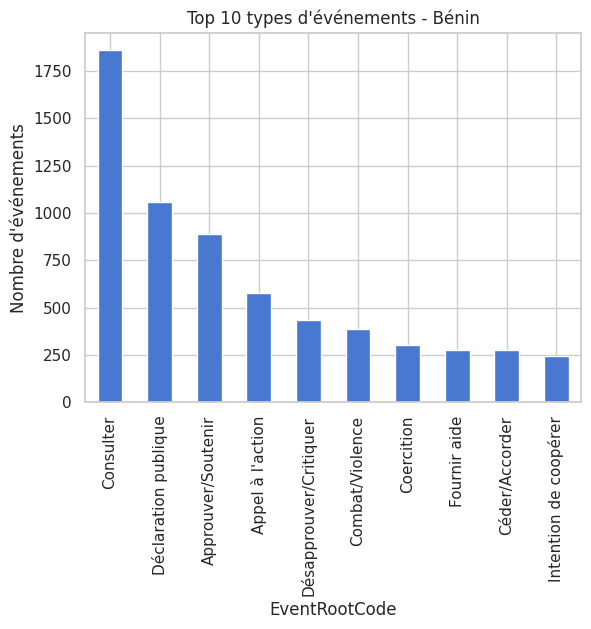

In [21]:
# Significations des événements dominants
domi_event = {
    1: "Déclaration publique",
    2: "Appel à l'action",
    3: "Intention de coopérer",
    4: "Consulter",
    5: "Approuver/Soutenir",
    7: "Fournir aide",
    8: "Céder/Accorder",
    11: "Désapprouver/Critiquer",
    17: "Coercition",
    19: "Combat/Violence"
}

data['EventRootCode'].map(domi_event).value_counts().head(10).plot(kind='bar')
plt.title("Top 10 types d'événements - Bénin")
plt.ylabel("Nombre d'événements")
plt.show()

On remarque qu'en 2025, le Bénin a été dominé par les interactions diplomatiques classiques (Consultation 04 et Déclarations 01). Toutefois, la présence notable des codes 19 (Combat) et 17 (Coercition) souligne l'existence de points de friction matériels importants.

In [22]:
# distribution de crise
data['crisis'].value_counts()

crisis
0    5467
1    1788
Name: count, dtype: int64

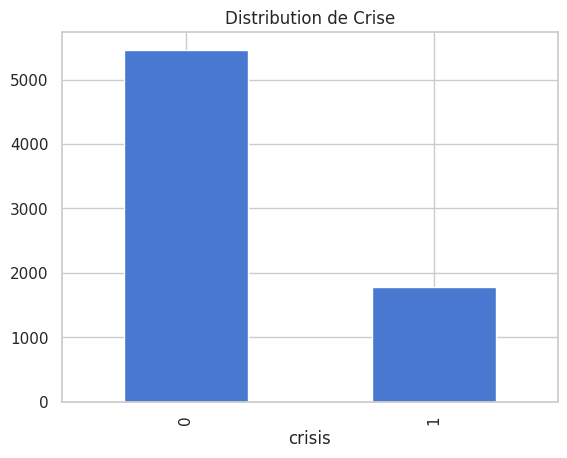

In [23]:
data['crisis'].value_counts().plot(kind='bar')
plt.title("Distribution de Crise")
plt.show()

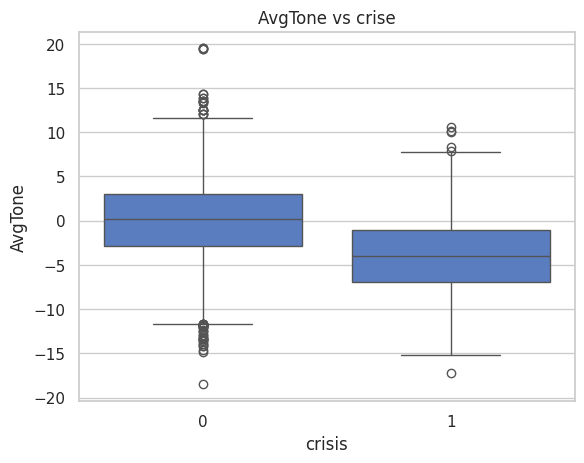

In [24]:
# Boxplot entrcrise et le ton des médias
sns.boxplot(x='crisis', y='AvgTone', data=data)
plt.title("AvgTone vs crise")
plt.show()

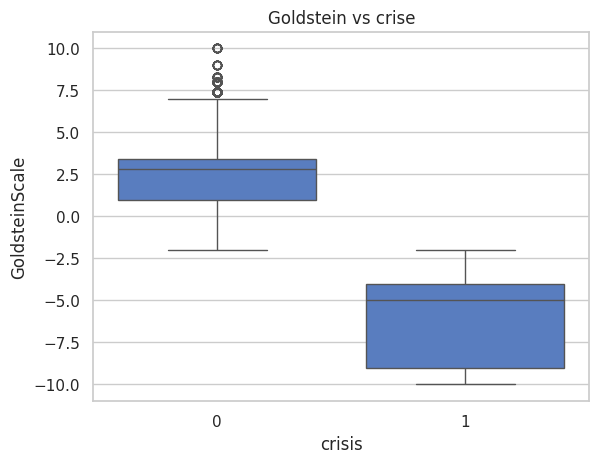

In [25]:
# Boxplot entre crise et l'impact des évènements
sns.boxplot(x='crisis', y='GoldsteinScale', data=data)
plt.title("Goldstein vs crise")
plt.show()

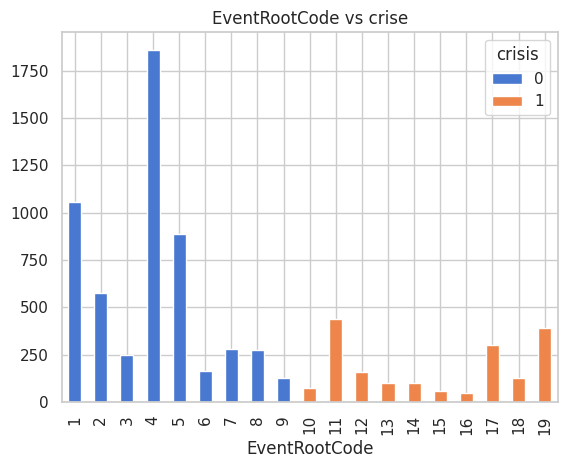

In [26]:
# relation entre crise les types d'evenements
pd.crosstab(data['EventRootCode'], data['crisis']).plot(kind='bar', stacked=True)
plt.title("EventRootCode vs crise")
plt.show()

In [27]:
# correlation entre les differents variables principales
data[['AvgTone','GoldsteinScale','EventRootCode','NumMentions','QuadClass','NumSources','crisis']].corr()

,AvgTone,GoldsteinScale,EventRootCode,NumMentions,QuadClass,NumSources,crisis
AvgTone,1.000000,0.350279,-0.335365,0.055995,-0.382725,-0.032747,-0.359370
GoldsteinScale,0.350279,1.000000,-0.735498,0.038934,-0.761398,-0.018672,-0.825775
EventRootCode,-0.335365,-0.735498,1.000000,-0.001792,0.964334,0.019859,0.889598
NumMentions,0.055995,0.038934,-0.001792,1.000000,-0.020608,0.101434,-0.023756
QuadClass,-0.382725,-0.761398,0.964334,-0.020608,1.000000,0.021300,0.930582
NumSources,-0.032747,-0.018672,0.019859,0.101434,0.021300,1.000000,0.031909
crisis,-0.359370,-0.825775,0.889598,-0.023756,0.930582,0.031909,1.000000


## Feature Engeneering

In [28]:
# Variables temporelles
def add_temporal_features(df):
    df = df.copy()
    df['dayofweek'] = df['SQLDATE'].dt.dayofweek
    df['month'] = df['SQLDATE'].dt.month
    df['quarter']      = df['SQLDATE'].dt.quarter      # annee en quatres periodes
    df['is_weekend']   = (df['dayofweek'] >= 5).astype(int) # weeend ou pas
    df['day_of_year']  = df['SQLDATE'].dt.dayofyear   # jour de l'annee
    # Encodage cyclique du jour de la semaine
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    return df

data = add_temporal_features(data)
print('Features temporelles ajoutées :', ['dayofweek', 'month', 'quarter','is_weekend','day_of_year',
                                          'dow_sin','dow_cos'])

Features temporelles ajoutées : ['dayofweek', 'month', 'quarter', 'is_weekend', 'day_of_year', 'dow_sin', 'dow_cos']


In [29]:
data.head()

,GLOBALEVENTID,SQLDATE,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,AvgTone,NumArticles,NumSources,QuadClass,Actor1Name,...,Domaine,Region,crisis,dayofweek,month,quarter,is_weekend,day_of_year,dow_sin,dow_cos
0,1218465492,2025-01-01,Benin,9.5,2.25,3.216374,1,1,1,BENIN,...,Politique & Gouvernance,Afrique de l'Ouest,0,2,1,1,0,1,0.974928,-0.222521
1,1218380721,2025-01-01,Benin,9.5,2.25,-5.305040,10,1,1,SPOKESMAN,...,Politique & Gouvernance,Panafricain,0,2,1,1,0,1,0.974928,-0.222521
2,1218465490,2025-01-01,Benin,9.5,2.25,3.216374,5,1,4,BENIN,...,Politique & Gouvernance,Afrique de l'Ouest,1,2,1,1,0,1,0.974928,-0.222521
3,1218458164,2025-01-01,Benin,9.5,2.25,-7.843137,3,1,1,DIPLOMAT,...,Politique & Gouvernance,Afrique de l'Ouest,0,2,1,1,0,1,0.974928,-0.222521
4,1218380442,2025-01-01,Benin,9.5,2.25,-5.305040,10,1,4,POLICE,...,Politique & Gouvernance,Panafricain,1,2,1,1,0,1,0.974928,-0.222521


In [30]:
# Encodage des variables acteurs importants identifies

# Mots-clés
GOV_KEYWORDS  = [
    'GOVERNMENT', 'MINISTER', 'PRESIDENT', 'OFFICIAL', 'BENIN', 'GOV',
    'GOVERNOR', 'CONGRESS','OPERATIVE',                        
]

MIL_KEYWORDS  = [
    'MILITARY', 'ARMY', 'POLICE', 'FORCE', 'SOLDIER', 'LAW ENFORCEMENT OFFICER', 
    'TERRORIST', 'PRISONER', 
]

INTL_KEYWORDS = [
    'UN', 'EU', 'ECOWAS', 'USAID', 'IMF', 'WORLD BANK', 'NGO', 'FRANCE', 'USA',
    'ECONOMIC COMMUNITY OF WEST AFRICAN STATES', 'BRUSSELS', 'LONDON', 'FRENCH', 
    'UNITED STATES', 'IVORIAN', 'NIGERIA', 'GHANA', 'GUINEA', 'SAUDI ARABIA',
]

CIVIL_KEYWORDS = [
    'VILLAGE', 'POPULATION','AFRICA', 'BANK',             
]

def actor_flag(series, keywords):
    pattern = '|'.join(keywords)
    return series.fillna('').str.upper().str.contains(pattern).astype(int)

data['actor1_is_gov']   = actor_flag(data['Actor1Name'], GOV_KEYWORDS)
data['actor1_is_mil']   = actor_flag(data['Actor1Name'], MIL_KEYWORDS)
data['actor1_is_intl']  = actor_flag(data['Actor1Name'], INTL_KEYWORDS)
data['actor1_is_civil'] = actor_flag(data['Actor1Name'], CIVIL_KEYWORDS)

data['actor2_is_gov']   = actor_flag(data['Actor2Name'], GOV_KEYWORDS)
data['actor2_is_mil']   = actor_flag(data['Actor2Name'], MIL_KEYWORDS)
data['actor2_is_intl']  = actor_flag(data['Actor2Name'], INTL_KEYWORDS)
data['actor2_is_civil'] = actor_flag(data['Actor2Name'], CIVIL_KEYWORDS)

# Vérification du nombre des differents acteurs
cols = ['actor1_is_gov', 'actor1_is_mil', 'actor1_is_intl', 'actor1_is_civil',
        'actor2_is_gov', 'actor2_is_mil', 'actor2_is_intl', 'actor2_is_civil']
print(data[cols].sum())

actor1_is_gov      2399
actor1_is_mil       336
actor1_is_intl     1829
actor1_is_civil     393
actor2_is_gov      1756
actor2_is_mil       240
actor2_is_intl     3255
actor2_is_civil     291
dtype: int64


In [31]:
# Encodage des variables themes importants identifies

CRISIS_THEMES   = [
    'TERROR', 'CONFLICT', 'COUP', 'WAR', 'ATTACK', 'PROTEST', 'UNREST', 'VIOLENCE', 
    'KILL', 'KIDNAP', 'JIHADIST', 'INSURGENC', 'ASSASSIN', 'MASSACRE', 
]

ELECTION_THEMES = [
    'ELECTION', 'VOTE', 'DEMOCRAT', 'POLITIC', 'OPPOSITION', 'PARTI', 'GOUVERN',          # gouvernance
]

ECON_THEMES     = [
    'ECONOMY', 'FINANCE', 'TRADE', 'INVEST', 'DEBT', 'POVERTY',
    'INFLATION',  'FOOD', 'AGRICULTUR', 'CORRUPTION', 
]
SECURITY_THEMES = [
    'SECURITY', 'MILITARY', 'POLICE', 'ARMY', 'BORDER',  'SMUGGL', 'TRAFFICK', 
]

def theme_flag(series, keywords):
    pattern = '|'.join(keywords)
    return series.fillna('').str.upper().str.contains(pattern).astype(int)

data['theme_crisis']    = theme_flag(data['Themes'], CRISIS_THEMES)
data['theme_election']  = theme_flag(data['Themes'], ELECTION_THEMES)
data['theme_economy']   = theme_flag(data['Themes'], ECON_THEMES)
data['theme_security']  = theme_flag(data['Themes'], SECURITY_THEMES)
data['theme_count']     = data['Themes'].fillna('').apply(lambda x: len(x.split(';')) if x else 0)

# Vérification de nombres de presences de chaque theme
cols = ['theme_crisis', 'theme_election', 'theme_economy', 'theme_security', 'theme_count']
print(data[cols].sum())
print('Features Themes OK')

theme_crisis        4285
theme_election      3987
theme_economy       4096
theme_security      3722
theme_count       262643
dtype: int64
Features Themes OK


### Agrégation des variables utiles pour le modèle

In [32]:
# agrégation des variations (par jour)
def build_daily_features(df):
    daily = df.groupby('SQLDATE').agg(
        # Impact et ton moyen des medias
        avg_goldstein    = ('GoldsteinScale', 'mean'),
        avg_tone         = ('AvgTone', 'mean'),
        # Volume mediatique par jour
        nb_evenements    = ('GLOBALEVENTID', 'count'),
        nb_mentions      = ('NumMentions', 'sum'),
        nb_sources       = ('NumSources', 'sum'),
        nb_articles      = ('NumArticles', 'sum'),
        # Conflits
        nb_conflits      = ('crisis', 'sum'),
        crisis_rate      = ('crisis', 'mean'),
        # proportion des themes par jour
        theme_crisis     = ('theme_crisis', 'mean'),
        theme_election   = ('theme_election', 'mean'),
        theme_economy    = ('theme_economy', 'mean'),
        theme_security   = ('theme_security', 'mean'),
        theme_count      = ('theme_count', 'mean'),
        # proportion d'apparition des acteurs par jour
        actor1_is_gov    = ('actor1_is_gov', 'mean'),
        actor1_is_mil    = ('actor1_is_mil', 'mean'),
        actor1_is_intl   = ('actor1_is_intl', 'mean'),
        actor1_is_civil  = ('actor1_is_civil', 'mean'),
        actor2_is_gov    = ('actor2_is_gov', 'mean'),
        actor2_is_mil    = ('actor2_is_mil', 'mean'),
        actor2_is_intl   = ('actor2_is_intl', 'mean'),
        actor2_is_civil  = ('actor2_is_civil', 'mean'),
        # Temporelles — identiques pour le même jour
        dayofweek      = ('dayofweek', 'first'),
        month            = ('month', 'first'),
        quarter          = ('quarter', 'first'),
        is_weekend       = ('is_weekend', 'first'),
        day_of_year      = ('day_of_year', 'first'),
        dow_sin          = ('dow_sin', 'first'),
        dow_cos          = ('dow_cos', 'first'),
    ).reset_index().sort_values('SQLDATE')
    
    return daily

data_agg = build_daily_features(data)

data_agg.shape

(349, 29)

In [33]:
data_agg.head()

,SQLDATE,avg_goldstein,avg_tone,nb_evenements,nb_mentions,nb_sources,nb_articles,nb_conflits,crisis_rate,theme_crisis,...,actor2_is_mil,actor2_is_intl,actor2_is_civil,dayofweek,month,quarter,is_weekend,day_of_year,dow_sin,dow_cos
0,2025-01-01,-1.186957,-3.817064,23,126,23,118,9,0.391304,0.695652,...,0.043478,0.391304,0.000000,2,1,1,0,1,0.974928,-0.222521
1,2025-01-02,0.481250,-2.910947,16,117,16,117,4,0.250000,0.687500,...,0.062500,0.562500,0.000000,3,1,1,0,2,0.433884,-0.900969
2,2025-01-03,1.169231,-0.786202,13,92,13,92,3,0.230769,0.692308,...,0.000000,0.538462,0.230769,4,1,1,0,3,-0.433884,-0.900969
3,2025-01-04,2.833333,0.616742,6,28,6,28,2,0.333333,0.500000,...,0.000000,0.333333,0.000000,5,1,1,1,4,-0.974928,-0.222521
4,2025-01-05,1.733333,3.050918,6,29,6,27,0,0.000000,0.666667,...,0.000000,0.500000,0.000000,6,1,1,1,5,-0.781831,0.623490


### Definition de la target

**L'objectif** est de prédire si dans 7 jours, le pays fera face à un conflit.

**conflit_detect** : 
  * 1 pour au moins un conflit détecter dans la semaine
  * 0 pour aucun conflit dans la semaine

Elle est définie en se basant sur le taux de crise journalière (crisis_rate). Si 40% des évènements publiés par les médias sont des conflits, alors la journée est déclarée comme un jour de crise.

In [34]:
SEUIL_CRISE = 0.4 # seuil de crise journalière
data_agg['crisis_day'] = (data_agg['crisis_rate'] > SEUIL_CRISE).astype(int) 

# Target 
data_agg['conflit_detect'] = (
    data_agg['crisis_day']
    .shift(-1)
    .rolling(7, min_periods=1)
    .max()
)

# Suppressions des NaN générés par le shift sur les derniers jours
data_agg = data_agg.dropna(subset=['conflit_detect'])
data_agg['conflit_detect'] = data_agg['conflit_detect'].astype(int)

print(data_agg['conflit_detect'].value_counts())
print(f"Taux de cronflit (target) : {data_agg['conflit_detect'].mean():.2%}")

conflit_detect
0    239
1    110
Name: count, dtype: int64
Taux de cronflit (target) : 31.52%


In [35]:
# Features de decalage temporelle

# Moyenne du GoldsteinScale sur 3, 7, 14 jours passés
data_agg['roll_3d_goldstein']  = data_agg['avg_goldstein'].rolling(3, min_periods=1).mean()
data_agg['roll_7d_goldstein']  = data_agg['avg_goldstein'].rolling(7, min_periods=1).mean()
data_agg['roll_14d_goldstein'] = data_agg['avg_goldstein'].rolling(14, min_periods=1).mean()

# Moyenne du ton sur 3, 7, 14 jours passés
data_agg['roll_3d_tone']  = data_agg['avg_tone'].rolling(3, min_periods=1).mean()
data_agg['roll_7d_tone']  = data_agg['avg_tone'].rolling(7, min_periods=1).mean()
data_agg['roll_14d_tone'] = data_agg['avg_tone'].rolling(14, min_periods=1).mean()

# Nombre d'événements sur 7 jours
data_agg['roll_7d_events'] = data_agg['nb_evenements'].rolling(7, min_periods=1).sum()

#  Lags (valeurs des jours précédents)
data_agg['goldstein_lag1'] = data_agg['avg_goldstein'].shift(1)  
data_agg['tone_lag1']      = data_agg['avg_tone'].shift(1)       
data_agg['crisis_lag1']    = data_agg['crisis_day'].shift(1)     

# Pression médiatique
data_agg['media_pressure'] = data_agg['nb_mentions'] / (data_agg['nb_sources'] + 1)

# Supprimer les NaN générés par les lags
data_agg = data_agg.dropna()

print(f'Shape après feature engineering : {data_agg.shape}')
print(f'Nombre de jours restants : {len(data_agg)}')

Shape après feature engineering : (348, 42)
Nombre de jours restants : 348


## Modèle

### Preparation du dataset

In [36]:
FEATURES = ['avg_goldstein', 'avg_tone', 'nb_evenements', 'nb_mentions', 
            'nb_sources', 'nb_articles', 'nb_conflits', 'crisis_rate', 'crisis_lag1',
            'roll_3d_goldstein', 'roll_7d_goldstein', 'roll_14d_goldstein','roll_3d_tone',
            'roll_7d_tone', 'roll_14d_tone', 'roll_7d_events',
            'goldstein_lag1', 'tone_lag1', 'media_pressure', 'theme_crisis', 
            'theme_election', 'theme_economy', 'theme_security', 'theme_count',
            'actor1_is_gov', 'actor1_is_mil', 'actor2_is_gov', 'actor2_is_mil',
            'dayofweek', 'month', 'quarter', 'is_weekend', 'day_of_year', 'dow_sin', 
            'dow_cos',
]

TARGET = 'conflit_detect'
X = data_agg[FEATURES]
y = data_agg[TARGET]

### Split train/test 

Les données étant temporelles, alors on entraine sur le passé et nous faisons le test sur le future (le train_test_split simple ne le fera)

In [37]:
# Couper à 80% du temps chronologiquement
split_date = data_agg['SQLDATE'].quantile(0.8)
train_mask = data_agg['SQLDATE'] < split_date
test_mask  = data_agg['SQLDATE'] >= split_date

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Train : {len(X_train)} jours, Test : {len(X_test)} jours')
print(f'Taux crise train : {y_train.mean():.2%}, test : {y_test.mean():.2%}')

Train : 278 jours, Test : 70 jours
Taux crise train : 37.05%, test : 10.00%


### Gestion du désequilibre

In [38]:
# Les poids de classe
classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print(f'Poids des classes : {class_weight_dict}')

Poids des classes : {np.int64(0): np.float64(0.7942857142857143), np.int64(1): np.float64(1.3495145631067962)}


### Entrainement des modèles

In [39]:
#  Random Forest 
model_rf = RandomForestClassifier(
    n_estimators=200,        
    max_depth=10,            
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

#  Regession logistic
model_log_reg = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    solver='lbfgs' 
)

model_log_reg.fit(X_train, y_train)

print('Modèles entraînés')

Modèles entraînés


### Evaluation des modèles

In [40]:
# Prédictions avec les données test
y_pred_rf   = model_rf.predict(X_test)
y_prob_rf   = model_rf.predict_proba(X_test)[:, 1]

y_pred_lg   = model_log_reg.predict(X_test)
y_prob_lg   = model_log_reg.predict_proba(X_test)[:, 1]

# AUC
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_gb = roc_auc_score(y_test, y_pred_lg)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Non-Conflit', 'Conflit']))
print(f'AUC : {auc_rf:.4f}\n')

print('=== Regression Logistic ===')
print(classification_report(y_test, y_pred_lg, target_names=['Non-Conflit', 'Conflit']))
print(f'AUC : {auc_gb:.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

 Non-Conflit       0.98      0.86      0.92        63
     Conflit       0.40      0.86      0.55         7

    accuracy                           0.86        70
   macro avg       0.69      0.86      0.73        70
weighted avg       0.92      0.86      0.88        70

AUC : 0.9048

=== Regression Logistic ===
              precision    recall  f1-score   support

 Non-Conflit       0.93      0.62      0.74        63
     Conflit       0.14      0.57      0.23         7

    accuracy                           0.61        70
   macro avg       0.54      0.60      0.49        70
weighted avg       0.85      0.61      0.69        70

AUC : 0.5952


### Importance des features du modèle RF

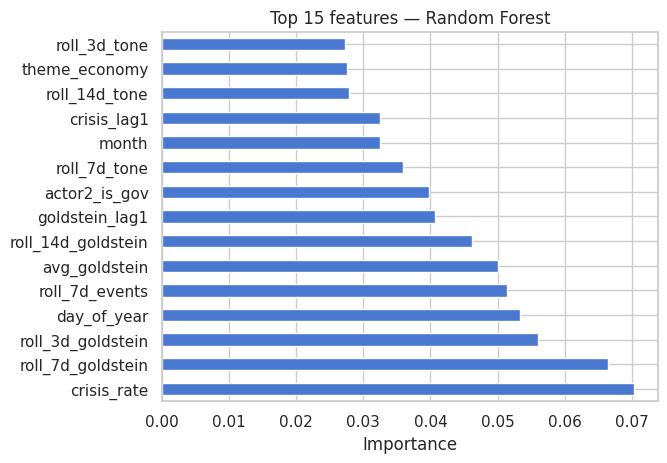

In [41]:
feat_imp = pd.Series(
    model_rf.feature_importances_,
    index=FEATURES
).sort_values(ascending=False).head(15)

feat_imp.plot(kind='barh')
plt.title('Top 15 features — Random Forest')
plt.xlabel('Importance')
plt.show()

## Visualisation

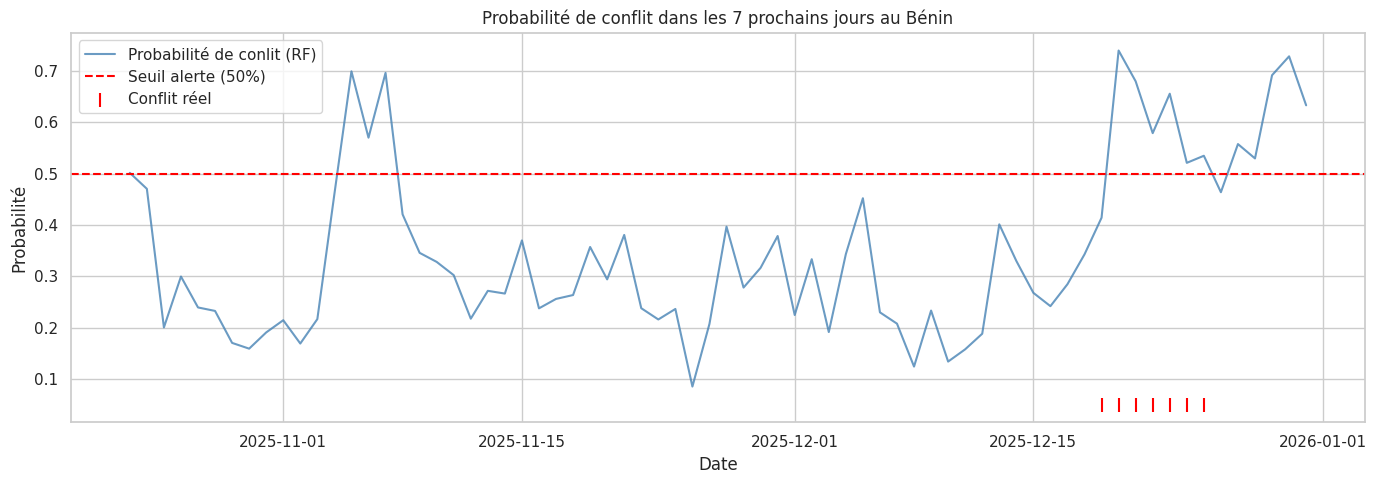

In [42]:
# Probabilités de conflit sur l'ensemble du dataset test
test_dates = data_agg[test_mask]['SQLDATE']

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_prob_rf, color='steelblue', label='Probabilité de conlit (RF)', alpha=0.8)
plt.axhline(0.5, color='red', linestyle='--', label='Seuil alerte (50%)')

# les vrais conflits
conflit_reels = test_dates[y_test == 1]
plt.scatter(conflit_reels, [0.05] * len(conflit_reels),
            color='red', marker='|', s=100, label='Conflit réel')

plt.title('Probabilité de conflit dans les 7 prochains jours au Bénin')
plt.ylabel('Probabilité')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

La figure ci-dessus représente la probabilité de conflit dans les 7 prochains jours estimée par le modèle de Random Forest sur la période de test (novembre 2025 - 1erjanvier 2026).
Plusieurs observations peuvent être faites :
Début novembre : les premières semaines affichent une probabilité autour de 0.5-0.7 alors qu'aucun conflit réel n'est visible. Peut-être parce que les variables roll_7d et roll_14d sont incomplètes sur cette période, ce qui peut perturber les prédictions initiales du modèle.
Mi-novembre à fin novembre : la probabilité descend autour de 0.2-0.3, reflétant une période relativement calme au Bénin.
Décembre 2025 : On remarque une montée progressive. La probabilité remonte significativement à partir de début décembre, ce qui coïncide avec la tentative de coup d'état au Bénin de décembre 2025. Les conflits réels (traits rouges) apparaissent autour du 15-20 décembre, et le modèle avait commencé à signaler une alerte plusieurs jours avant.
Fin décembre - début janvier 2026 : la probabilité dépasse le seuil de 50% et reste haute, cohérent avec les suites de la crise politique de décembre.

## Sauvegarde

In [43]:
# Sauvegarder le modèle
joblib.dump(model_rf, 'random_forest_conflit.pkl')
# Sauvegarder le dataset agrege
data_agg.to_csv('data_daily_features.csv', index=False)